<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-257-Machine-Learning/blob/main/W2S1_SU26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CMPE-257, Machine Learning, Summer 2026
## Week 2: Statistical Learning Theory

In this workbook, you will be exporing a simple regression problem:

- approximating an unknown function
- model complexity and learning
- sample complexity and learning
- exploring the effects of noise

In [1]:
# YOUR NAME: <Meenakshi Rajpurohit>

In [2]:
# Loading required modules
import random as rd
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import pylab

## PART 1: Approximating an Unknown Function

In [3]:
# The following six functions provide the basis for the exporatory work you will be
# conducting in this coding session, study them and make sure you understand what they do

# GETGXVALS: computes g(x) for a given g() and set of x values
# GETFXVALS: computes f(x) = cos(x) for a given set of x values
# GETNOISE: computes noise (gaussian distribution, zero mean and specified variance)
# GETDATA: uses the three previos functions to compute a dataset and all associated values
# GETMSE: computes the mean square error between two lists of values
# GETOPTGX: finds the best fit (constant, linear, or quadratic) for a given set of points

# GETGXVALS: evaluates a given hypothesis gx over a set of provided data points xvals
# - gx: a list containing the coeficients of the model [a,...] -> a + b x + c x^2 + ...
# - xvals: a list of x values for which g(x) is to be computed
def getgxvals(gx,xvals):
    return [sum([r*x**i for i,r in enumerate(gx)]) for x in xvals]

# GETFXVALS: evaluates the generative funtion f(x)=cos(x) over a set of data points xvals
# - xvals: a list of x values for which f(x) is to be computed
def getfxvals(xvals):
    return [np.cos(x) for x in xvals]

# GETNOISE: produces random samples with gaussian distribution, zero mean and specified variance
# - vr: the desired variance value (float) for the resuting noise sequence
# - nspl: the desired number of random samples (int) in the resuting noise sequence
def getnoise(vr,nspl):
    tmp = [rd.gauss(0.0,vr**0.5) for x in range(nspl)]
    return [x-np.mean(tmp) for x in tmp]

# GETDATA: generates a dataset (dict) for experimental purposes. Input parameters include:
# - xvals: either the number of data points (int) or the specific x values to be used (list)
# - rnd: if TRUE, a random set of points is generated, if FALSE points are uniformly
#   distributed between xmin and xman (if xvals is a list, rnd is ignored)
# - nvr: the desired variance for the additive noise component n -> y = f(x) + n
# - xmin: minimum value of x to be considered (if x values are generated, i.e. xvals is int)
# - xmax: maximum value of x to be considered (if x values are generated, i.e. xvals is int)
def getdata(xvals,rnd=False,nvr=0.0,xmin=0.0,xmax=4.55):
    if type(xvals) is list:
        ndata = len(xvals)
        xx = xvals
    elif rnd:
        ndata = int(xvals)
        xx = sorted([rd.uniform(xmin,xmax) for x in range(ndata)])
    else:
        ndata = int(xvals)
        xx = [(xmax-xmin)/ndata*t-xmin for t in range(ndata)]
    ff = getfxvals(xx)
    nn = getnoise(nvr,ndata)
    yy = [x+y for x,y in zip(ff,nn)]
    return {'x':xx,'f':ff,'n':nn,'y':yy,'nvar':nvr}

# GETMSE: computes de mean square error (MSE) between two lists of values
# - yvals: the set of values being evaluated
# - yrefs: the set of reference values to conduct the evaluation
def getmse(yvals,yrefs):
    return sum([(yr-yv)**2 for yr,yv in zip(yrefs,yvals)])/len(yrefs)

# GETOPTGX: computes the optimal model (best fit) for a given set of data points
# - xvals: a list containing the x coordinates of the data points
# - yvals: a lits containing the y coordinates of the data points
# - order: the order of the model to be used (0: constant, 1: linear, 2: quadratic)
# Note 1: this function uses the closed solutions derived in class
# Note 2: models are returned as a list of coefficients, starting with the lowest order one
def getoptgx(xvals,yvals,order):
    ns = len(xvals)
    if order==0:
        k = sum(yvals)/len(yvals)
        gx = [k]
    elif order==1:
        sx = sum(xvals)
        sy = sum(yvals)
        sxy = sum([x*y for x,y in zip(xvals,yvals)])
        sx2 = sum([x**2 for x in xvals])
        m = (ns*sxy-sx*sy)/(ns*sx2-sx**2)
        b = (sy-m*sx)/ns
        gx = [b,m]
    elif order==2:
        sx = sum(xvals)
        sx2 = sum([x**2 for x in xvals])
        sx3 = sum([x**3 for x in xvals])
        sx4 = sum([x**4 for x in xvals])
        sy = sum(yvals)
        syx = sum([y*x for x,y in zip(xvals,yvals)])
        syx2 = sum([y*x**2 for x,y in zip(xvals,yvals)])
        bn = (ns*syx2-sy*sx2)*(ns*sx3-sx*sx2)-(ns*syx-sy*sx)*(ns*sx4-sx2**2)
        bd = (ns*sx3-sx*sx2)**2-(ns*sx2-sx**2)*(ns*sx4-sx2**2)
        b = bn/bd
        a = (ns*syx-sy*sx-b*(ns*sx2-sx**2))/(ns*sx3-sx*sx2)
        c = (sy-a*sx2-b*sx)/ns
        gx = [c,b,a]
    return gx

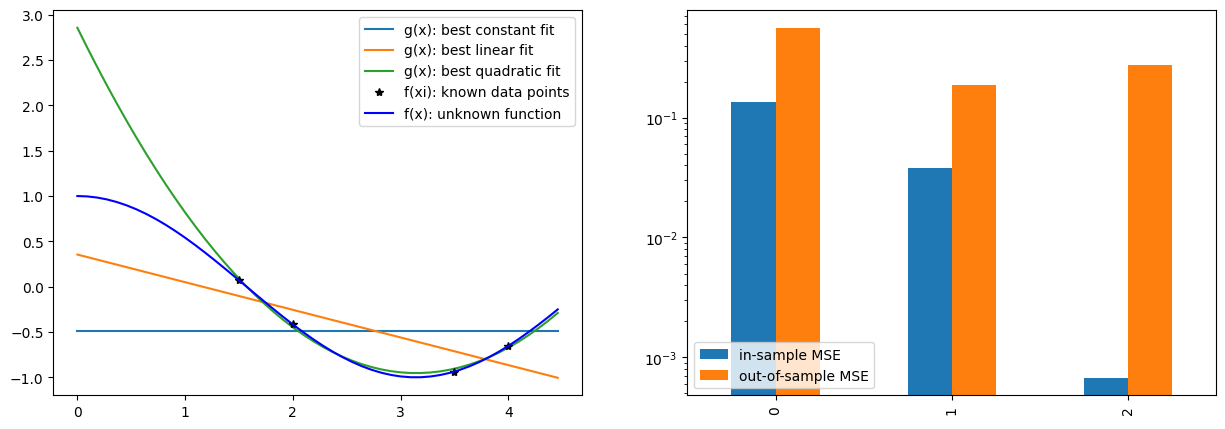

In [4]:
# Exercise #1: reproduce results presented in class for approximating an unknown f(X),
# use the folowing values of x for the in-sample dataset [1.50,2.00,3.50,4.00], and
# consider three different model types: constant, linear, and quadratic

fig, ax = plt.subplots(1,2,figsize=(15,5))
tags = ['constant','linear','quadratic']
results = []
models = []

in_sample_data = [1.50,2.00,3.50,4.00]

in_sample = getdata(in_sample_data)
out_sample = getdata(50)

for k in range(3):

    model = getoptgx(in_sample['x'],in_sample['y'],k)
    inmse = getmse(in_sample['y'],getgxvals(model,in_sample['x']))

    predictions = getgxvals(model,out_sample['x'])
    outmse = getmse(out_sample['y'],predictions)

    results.append({'Model Order':tags[k],'in-sample MSE':inmse,'out-of-sample MSE':outmse})
    models.append(model)

    ax[0].plot(out_sample['x'],predictions,label='g(x): best '+tags[k]+' fit')

ax[0].plot(in_sample['x'],in_sample['y'],'*k',label='f(xi): known data points')
ax[0].plot(out_sample['x'],out_sample['f'],'-b',label='f(x): unknown function')
ax[0].legend()

pd.DataFrame(results).plot(kind='bar',logy=True, ax=ax[1], legend=True)
pylab.legend(loc='lower left')
plt.show()

In [5]:
# Exercise 1 (continuation): display the obtained results in tabular form
display(pd.DataFrame(results).T)

,0,1,2
Model Order,constant,linear,quadratic
in-sample MSE,0.136458,0.037702,0.000675
out-of-sample MSE,0.562852,0.186096,0.275623


In [6]:
# How results in exercises #1 compare to the example presented in class?
# <Results are very similar with only minor numerical differences from different data splits.>

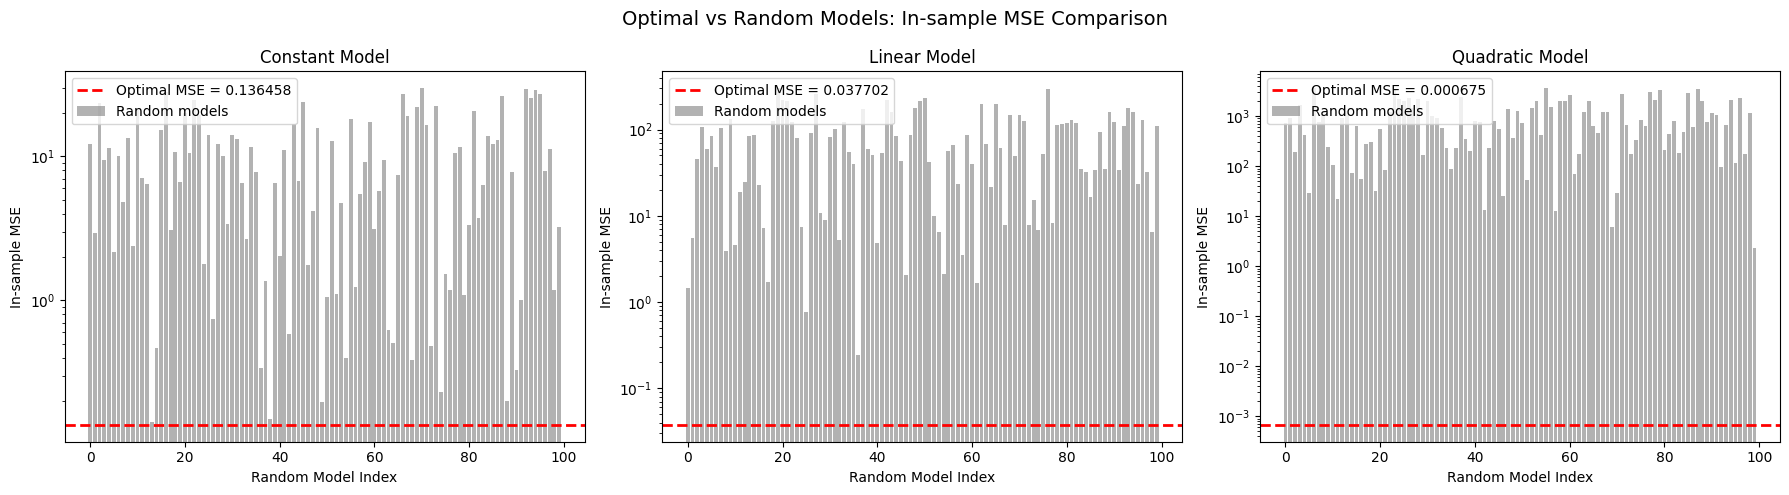

In [7]:
# Exercise #2: verify that the models obtained in exercise #1 are actually optimal fits
# for the given in-sample dataset (Suggestion: for each of the three cases, generate ~100
# random models and show the resulting MSE is always equal or greater than the MSE of the
# corresponding optimal model). Illustrate your results in a graph comparing the optimal
# fit error with respect to the randomly generated models' fit errors.

# add your code here...

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
n_random = 100

for k in range(3):
    opt_model = models[k]
    opt_mse = getmse(in_sample['y'], getgxvals(opt_model, in_sample['x']))

    # Generate 100 random models of same order and compute their in-sample MSE
    random_mses = []
    for _ in range(n_random):
        random_coefs = list(np.random.uniform(-5, 5, size=k + 1))
        random_preds = getgxvals(random_coefs, in_sample['x'])
        random_mses.append(getmse(in_sample['y'], random_preds))

    # Plot
    axes[k].bar(range(n_random), random_mses, color='gray', alpha=0.6, label='Random models')
    axes[k].axhline(y=opt_mse, color='red', linewidth=2, linestyle='--',
                     label=f'Optimal MSE = {opt_mse:.6f}')
    axes[k].set_title(f'{tags[k].capitalize()} Model')
    axes[k].set_xlabel('Random Model Index')
    axes[k].set_ylabel('In-sample MSE')
    axes[k].legend()
    axes[k].set_yscale('log')

plt.suptitle('Optimal vs Random Models: In-sample MSE Comparison', fontsize=14)
plt.tight_layout()
plt.show()


In [8]:
# Any observations about your results from exercises #2?
# <For all three model orders, every random model's MSE lies above the optimal MSE (red line), confirming that the fits from getoptgx are truly optimal. Higher-order models show a larger gap between random and optimal MSE, meaning randomly guessing good coefficients gets harder as model complexity increases.>

In-sample points found: [0.17, 1.14, 2.64, 3.29]


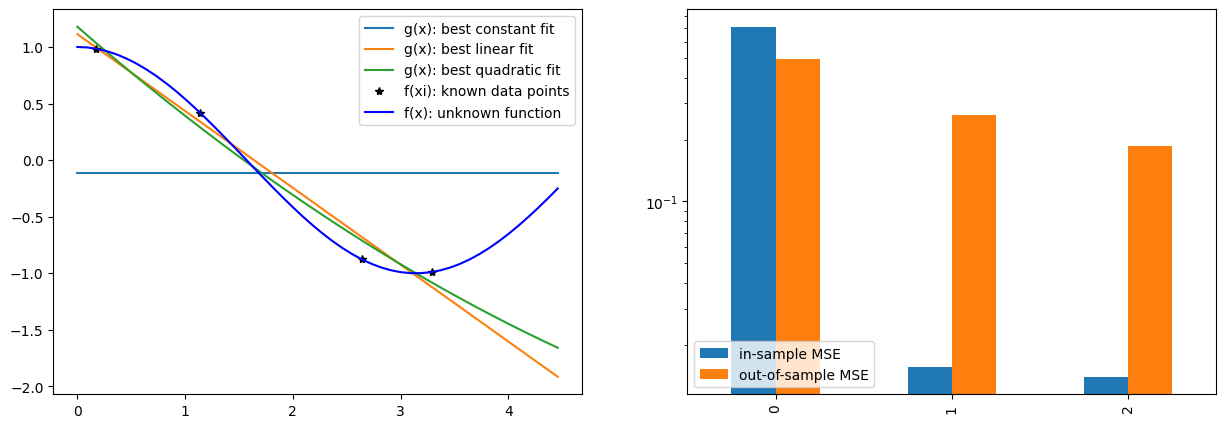

In [9]:
# Exercise #3: reproduce results from exercise #1 but, this time, find a different set of
# four in-sample data points such that the quadratic model exhibits the best out-of-sample MSE

# add your code here...

out_sample = getdata(50)
found = False

while not found:
    x_trial = sorted([rd.uniform(0.0, 4.55) for _ in range(4)])
    trial_data = getdata(x_trial)

    out_mses = []
    for k in range(3):
        model = getoptgx(trial_data['x'], trial_data['y'], k)
        preds = getgxvals(model, out_sample['x'])
        out_mses.append(getmse(out_sample['y'], preds))

    # Check if quadratic has the lowest out-of-sample MSE
    if out_mses[2] < out_mses[1] and out_mses[2] < out_mses[0]:
        found = True

print(f"In-sample points found: {[round(x,2) for x in x_trial]}")

# Now reproduce Exercise #1 with these points
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
in_sample = getdata(x_trial)
results = []
models3 = []

for k in range(3):
    model = getoptgx(in_sample['x'], in_sample['y'], k)
    inmse = getmse(in_sample['y'], getgxvals(model, in_sample['x']))
    preds = getgxvals(model, out_sample['x'])
    outmse = getmse(out_sample['y'], preds)

    results.append({'Model Order': tags[k], 'in-sample MSE': inmse, 'out-of-sample MSE': outmse})
    models3.append(model)
    ax[0].plot(out_sample['x'], preds, label='g(x): best ' + tags[k] + ' fit')

ax[0].plot(in_sample['x'], in_sample['y'], '*k', label='f(xi): known data points')
ax[0].plot(out_sample['x'], out_sample['f'], '-b', label='f(x): unknown function')
ax[0].legend()

pd.DataFrame(results).plot(kind='bar', logy=True, ax=ax[1], legend=True)
pylab.legend(loc='lower left')
plt.show()



In [10]:
# Exercise #3 (continuation): display the obtained results in tabular form
display(pd.DataFrame(results).T)

,0,1,2
Model Order,constant,linear,quadratic
in-sample MSE,0.709627,0.015612,0.01395
out-of-sample MSE,0.493055,0.263467,0.186921


In [11]:
# How these results compare to your previous results from exercise #1?
# <In Exercise #1, the linear model had the best out-of-sample MSE, and the quadratic overfitted. Here, with different data points, the quadratic model achieves the best out-of-sample MSE. This shows that model performance depends on the choice of training data.  >

In-sample points found: [0.48, 1.41, 1.91, 2.52]


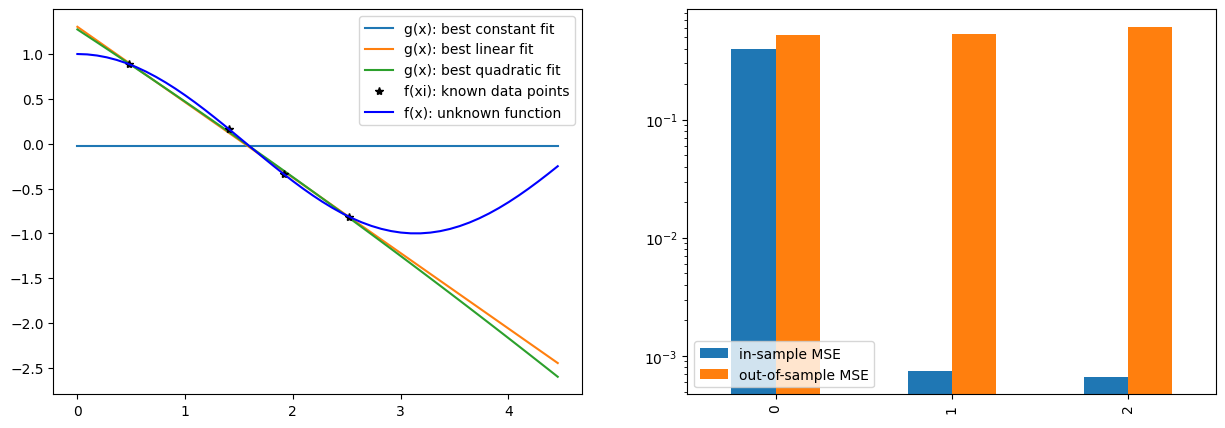

In [12]:
# Exercise #4: can you find a set of four in-sample data points such that the constant model
# exhibits the best out-of-sample MSE? If you succed in doing so, repeat exercises #3 here
# for such in-sample dataset

# add your code here...

out_sample = getdata(50)
found = False
attempts = 0
max_attempts = 1000000

while not found and attempts < max_attempts:
    x_trial = sorted([rd.uniform(0.0, 4.55) for _ in range(4)])
    trial_data = getdata(x_trial)

    out_mses = []
    for k in range(3):
        model = getoptgx(trial_data['x'], trial_data['y'], k)
        preds = getgxvals(model, out_sample['x'])
        out_mses.append(getmse(out_sample['y'], preds))

    if out_mses[0] < out_mses[1] and out_mses[0] < out_mses[2]:
        found = True
    attempts += 1

if found:
    print(f"In-sample points found: {[round(x,2) for x in x_trial]}")

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    in_sample = getdata(x_trial)
    results = []

    for k in range(3):
        model = getoptgx(in_sample['x'], in_sample['y'], k)
        inmse = getmse(in_sample['y'], getgxvals(model, in_sample['x']))
        preds = getgxvals(model, out_sample['x'])
        outmse = getmse(out_sample['y'], preds)

        results.append({'Model Order': tags[k], 'in-sample MSE': inmse, 'out-of-sample MSE': outmse})
        ax[0].plot(out_sample['x'], preds, label='g(x): best ' + tags[k] + ' fit')

    ax[0].plot(in_sample['x'], in_sample['y'], '*k', label='f(xi): known data points')
    ax[0].plot(out_sample['x'], out_sample['f'], '-b', label='f(x): unknown function')
    ax[0].legend()

    pd.DataFrame(results).plot(kind='bar', logy=True, ax=ax[1], legend=True)
    pylab.legend(loc='lower left')
    plt.show()


In [13]:
# Exercise #4 (continuation): display the obtained results in tabular form
display(pd.DataFrame(results).T)

,0,1,2
Model Order,constant,linear,quadratic
in-sample MSE,0.397506,0.000744,0.000667
out-of-sample MSE,0.517676,0.531272,0.612944


In [14]:
# How these results compare to your previous results from exercises #1 and #3?
# <In all three exercises, in-sample MSE decreases with model complexity (constant > linear > > quadratic). However, the best out-of-sample model differs each time: linear wins in Ex#1, quadratic in Ex#3, and constant in Ex#4. This demonstrates that which model generalizes best depends entirely on the training data points chosen no single model order is universally best, and lower training error does not guarantee better generalization.

## PART 2: Model Complexity and Learning

In [15]:
# SIMULATIONS: this function allows you to run multiple simulations while varying certain
# parameters, take a look at it and make sure you understand how it works
# - ind: the in-sample dataset (a dictionary as produced by GETDATA) If this input variable
#   is not provided, a random in-sample dataset of size nsamples will be used
# - osd: the out-of-sample dataset (a dictionary as produced by GETDATA) If this input varable
#   is not provided, a uniformly distributed dataset of size 100 will be used
# - morder: a list containing the model orders to be considered (default value is [0,1,2])
# - nsamples: the size of the in-sample dataset (ignored if an in-sampled dataset is passed)
# - niter: the total number of iterations to be conducted per model type (notice this variable
#   value is overrited and made equal to 1 if an in-sample dataset is passed)
# - pflag: if TRUE, simulation plots are generated; if FALSE, no plot is generated

def simulations(ind={},osd={},morder=[0,1,2],nsamples=4,niter=1,pflag=False):

    if len(ind)>0:
        niter = 1
        rndflag = False
        nsamples = len(ind['x'])
    else:
        rndflag = True
    if len(osd)==0:
        osd = getdata(100)
    tags = ['constant','linear','quadratic']
    results = []

    if pflag:
        fig, ax = plt.subplots(1,3,figsize=(15,5))

    for modelorder in morder:
        models = []
        in_mse = []
        out_mse = []
        all_predictions = []

        for k in tqdm(range(niter),desc=tags[modelorder].rjust(10)+'|'+str(nsamples).rjust(2)):

            if rndflag:
                ind=getdata(nsamples,rnd=True,nvr=osd['nvar'],xmin=osd['x'][0],xmax=osd['x'][-1])

            model = getoptgx(ind['x'],ind['y'],modelorder)
            in_mse.append(getmse(ind['y'],getgxvals(model,ind['x'])))

            predictions = getgxvals(model,osd['x'])
            out_mse.append(getmse(osd['y'],predictions))
            models.append(model)

            all_predictions.append(predictions)

        mean_model = np.array(models).mean(0)
        mean_predictions = getgxvals(mean_model,osd['x'])

        if pflag:
            for n,vals in enumerate(all_predictions[:50]):
                if n==0: ax[modelorder].plot(osd['x'],vals,'-y',label='Individual Models')
                else: ax[modelorder].plot(osd['x'],vals,'-y')
            ax[modelorder].plot(osd['x'],osd['f'],'-k',label='Generating Function')
            ax[modelorder].plot(osd['x'],osd['y'],'.k',label='Out-of-sample Data')
            ax[modelorder].plot(osd['x'],mean_predictions,'-r',label='Average Model')
            ax[modelorder].set_ylim(-4,4)
            ax[modelorder].legend(loc='upper right')

        results.append({'Model Order':modelorder,
                        'N Samples':nsamples,
                        'BIAS':getmse(osd['f'],mean_predictions),
                        'VAR':np.array(all_predictions).var(0).mean(),
                        'Noise':np.var(osd['n']),
                        'out_MSE':np.mean(out_mse),
                        'in_MSE':np.mean(in_mse)})

    tagseq = ['Model Order','N Samples','in_MSE','out_MSE','BIAS','VAR','Noise']
    return pd.DataFrame(results)[tagseq]

  constant| 4: 100%|██████████| 100000/100000 [00:03<00:00, 29042.74it/s]
    linear| 4: 100%|██████████| 100000/100000 [00:04<00:00, 23276.34it/s]
 quadratic| 4: 100%|██████████| 100000/100000 [00:04<00:00, 20115.25it/s]


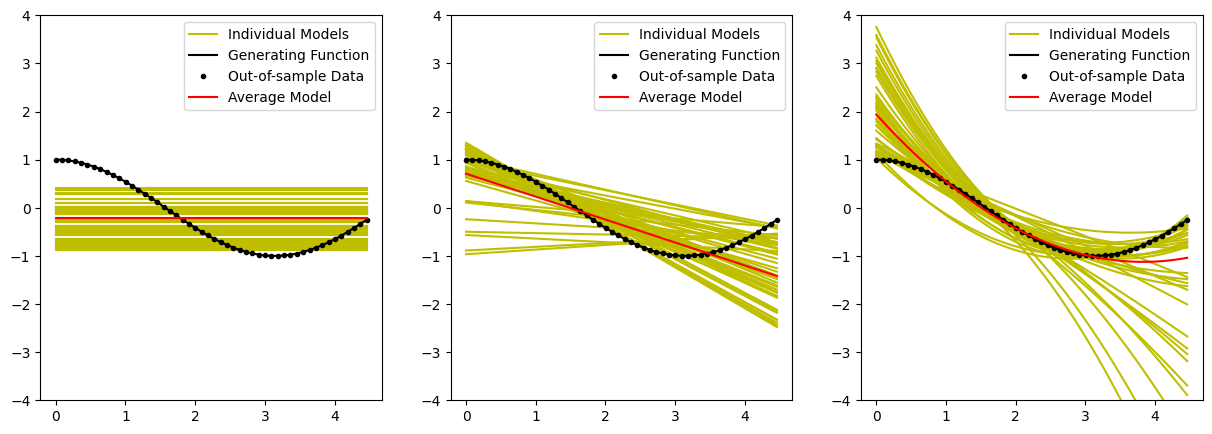

In [16]:
# Exercise #5: use the SIMULATIONS function above to compute average out-of-sample MSE, average
# in-sample MSE, BIAS and VAR. Consider in-sample datasets of 4 points and an out-of-sample
# dataset of 50 uniformly distributed points with zero noise variance. Run a large number (~100K)
# of simulations for each model type (constant, linear, and quadratic).

out_sample = getdata(50,nvr=0.0)
e5 = simulations(osd=out_sample,nsamples=4,niter=100000,pflag=True)

In [17]:
# Exercise #5 (continuation): add an additional column to the resulting dataframe with the
# sum of the BIAS, VAR and Noise columns; and another additional column containing the MSE
# between out-sample MSE and the newly computed BIAS+VAR+Noise. Display the dataframe.

# add your code here...
e5['BIAS+VAR+Noise'] = e5['BIAS'] + e5['VAR'] + e5['Noise']
e5['Diff (out_MSE - B+V+N)'] = e5['out_MSE'] - e5['BIAS+VAR+Noise']
e5


,Model Order,N Samples,in_MSE,out_MSE,BIAS,VAR,Noise,BIAS+VAR+Noise,Diff (out_MSE - B+V+N)
0,0,4,0.360236,0.605360,0.485295,0.120065,0.0,0.605360,9.992007e-16
1,1,4,0.046368,0.377254,0.158541,0.218714,0.0,0.377254,3.497203e-15
2,2,4,0.002508,0.404124,0.114151,0.289973,0.0,0.404124,-1.998401e-15


In [18]:
# What are your main observations from exercises #5?
# <1. BIAS decreases with model complexity (0.49 → 0.16 → 0.11) since more flexible models can better approximate cos(x), as seen by the average model (red line) getting closer to f(x) (black line). 2. VAR increases with model complexity (0.12 → 0.22 → 0.29) since higher order models are more sensitive to which training points are sampled. 3. The linear model has the best out-of-sample MSE, striking the best bias-variance tradeoff — quadratic reduces bias slightly but adds too much variance.  >

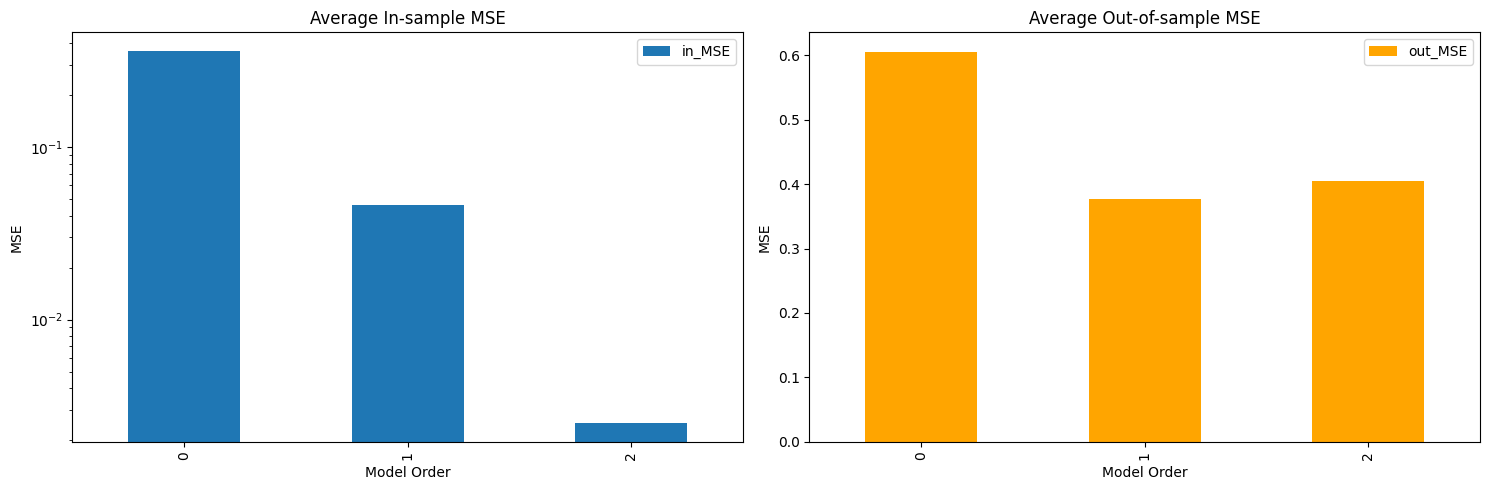

In [19]:
# Exercise #6: use the resuls from exercise #5 to generate MSE bar plots for the three models
# under consideration. Depict the average in-sample MSEs in one bar plot and the average
# out-of-sample MSEs in the second one.

# add your code here...
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

e5.plot(x='Model Order', y='in_MSE', kind='bar', ax=ax[0], legend=True, logy=True)
ax[0].set_title('Average In-sample MSE')
ax[0].set_xlabel('Model Order')
ax[0].set_ylabel('MSE')

e5.plot(x='Model Order', y='out_MSE', kind='bar', ax=ax[1], legend=True, color='orange')
ax[1].set_title('Average Out-of-sample MSE')
ax[1].set_xlabel('Model Order')
ax[1].set_ylabel('MSE')

plt.tight_layout()
plt.show()


In [20]:
# How results from exercises #6 compare to those presented and discussed in class?
# <Both show the same patterns: in-sample MSE decreases with complexity (constant > linear > quadratic), and linear has the best out-of-sample MSE. My values are very close to the classroom values. The quadratic out-of-sample MSE differs slightly (0.402 vs 0.425) but the conclusion is the same linear generalizes best, and the gap between linear and quadratic is smaller on average than in single-run experiments from Exercise #1. >

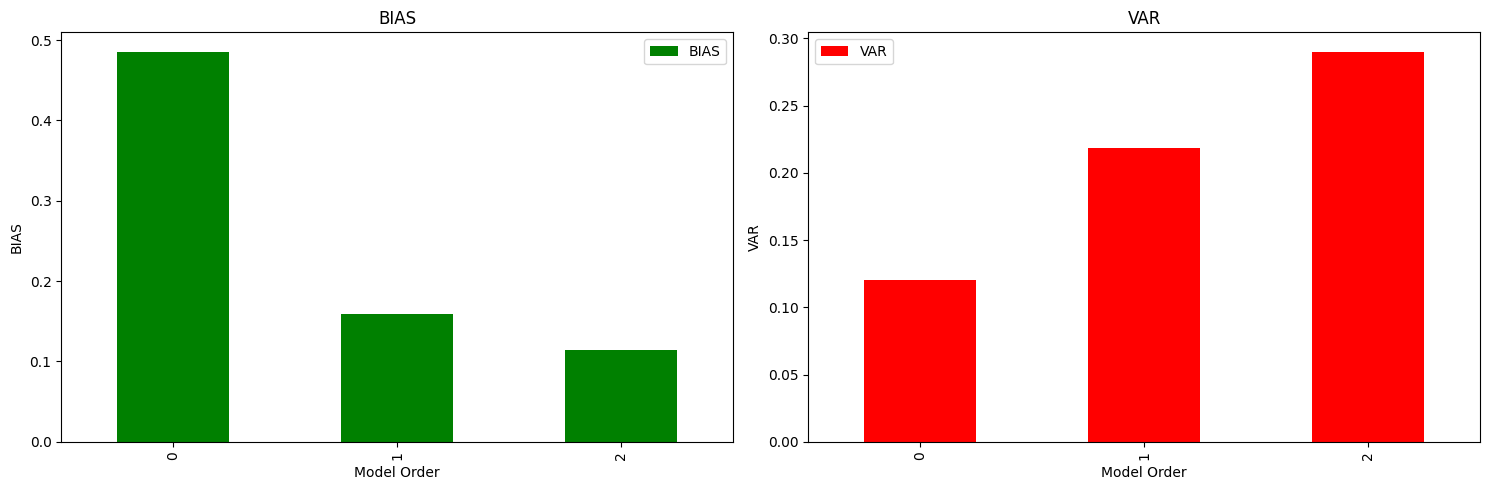

In [21]:
# Exercise #7: use the resuls from exercise #5 to generate MSE bar plots for the three models
# under consideration. Depict the BIAS in one bar plot and the VAR in the second one.

# add your code here...

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

e5.plot(x='Model Order', y='BIAS', kind='bar', ax=ax[0], legend=True, color='green')
ax[0].set_title('BIAS')
ax[0].set_xlabel('Model Order')
ax[0].set_ylabel('BIAS')

e5.plot(x='Model Order', y='VAR', kind='bar', ax=ax[1], legend=True, color='red')
ax[1].set_title('VAR')
ax[1].set_xlabel('Model Order')
ax[1].set_ylabel('VAR')

plt.tight_layout()
plt.show()

In [22]:
# How results from exercises #7 compare to those presented and discussed in class?
# <Both show the same bias-variance tradeoff: BIAS decreases with complexity while VAR increases My values are very close to the
# classroom values (e.g., BIAS: 0.485 vs 0.486, VAR: 0.120 vs 0.118). Minor differences are due to randomness in simulations, but the pattern is identical confirming that simpler models underfit (high bias) and complex models overfit (high variance).>

## PART 3: Sample Complexity and Learning

In [23]:
# Exercise 8: implement a loop to conduct similar simulations to the ones in exercise #5
# while varying the nsample parameter (sugested values [3,4,5,6,7,8,9,10,12,15,20]). Consider
# an out-of-sample dataset of 50 uniformly distributed points with zero noise variance. Again,
# run a large number (~100K) of simulations for each model type and in-sample dataset size.

# add your code here...
out_sample = getdata(50, nvr=0.0)
nsample_values = [3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20]

e8 = pd.DataFrame()

for ns in nsample_values:
    result = simulations(osd=out_sample, nsamples=ns, niter=100000)
    e8 = pd.concat([e8, result], ignore_index=True)

e8


  constant| 3: 100%|██████████| 100000/100000 [00:03<00:00, 32074.24it/s]
    linear| 3: 100%|██████████| 100000/100000 [00:03<00:00, 26215.60it/s]
 quadratic| 3: 100%|██████████| 100000/100000 [00:04<00:00, 22098.74it/s]
  constant| 4: 100%|██████████| 100000/100000 [00:03<00:00, 28825.03it/s]
    linear| 4: 100%|██████████| 100000/100000 [00:04<00:00, 23866.12it/s]
 quadratic| 4: 100%|██████████| 100000/100000 [00:04<00:00, 20252.46it/s]
  constant| 5: 100%|██████████| 100000/100000 [00:03<00:00, 25711.81it/s]
    linear| 5: 100%|██████████| 100000/100000 [00:04<00:00, 21576.27it/s]
 quadratic| 5: 100%|██████████| 100000/100000 [00:05<00:00, 18446.73it/s]
  constant| 6: 100%|██████████| 100000/100000 [00:04<00:00, 23440.18it/s]
    linear| 6: 100%|██████████| 100000/100000 [00:05<00:00, 19827.13it/s]
 quadratic| 6: 100%|██████████| 100000/100000 [00:05<00:00, 17148.84it/s]
  constant| 7: 100%|██████████| 100000/100000 [00:04<00:00, 21513.68it/s]
    linear| 7: 100%|██████████| 100000

,Model Order,N Samples,in_MSE,out_MSE,BIAS,VAR,Noise
0,0,3,3.201390e-01,0.645460,0.485310,0.160149,0.0
1,1,3,2.547195e-02,0.529329,0.183635,0.345694,0.0
2,2,3,1.453849e-20,0.660607,0.187355,0.473252,0.0
3,0,4,3.608297e-01,0.606112,0.485275,0.120837,0.0
4,1,4,4.583709e-02,0.377077,0.158879,0.218198,0.0
5,2,4,2.504338e-03,0.401206,0.113161,0.288046,0.0
6,0,5,3.838651e-01,0.580870,0.485301,0.095570,0.0
7,1,5,6.113575e-02,0.299655,0.148808,0.150847,0.0
8,2,5,5.422089e-03,0.272893,0.079406,0.193487,0.0
9,0,6,4.010525e-01,0.565434,0.485298,0.080136,0.0


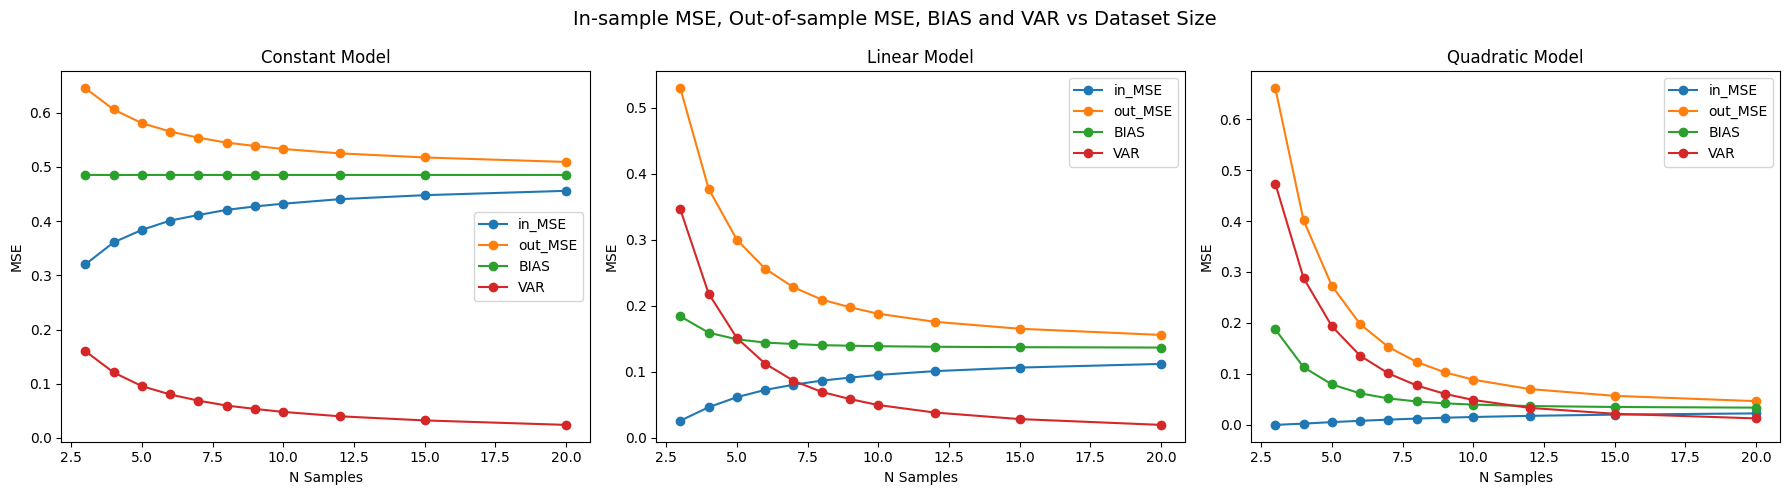

In [24]:
# Exercise 8 (continuation): generate three plots, one for each model type, displaying the
# resulting curves for average in-sample MSE, avergare out-of-sample MSE, BIAS and VAR as
# a funtion of the nsamples parameter (i.e. the in-sample dataset size)

# add your code here...
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
tags = ['Constant', 'Linear', 'Quadratic']

for k in range(3):
    df = e8[e8['Model Order'] == k]
    axes[k].plot(df['N Samples'], df['in_MSE'], '-o', label='in_MSE')
    axes[k].plot(df['N Samples'], df['out_MSE'], '-o', label='out_MSE')
    axes[k].plot(df['N Samples'], df['BIAS'], '-o', label='BIAS')
    axes[k].plot(df['N Samples'], df['VAR'], '-o', label='VAR')
    axes[k].set_title(f'{tags[k]} Model')
    axes[k].set_xlabel('N Samples')
    axes[k].set_ylabel('MSE')
    axes[k].legend()

plt.suptitle('In-sample MSE, Out-of-sample MSE, BIAS and VAR vs Dataset Size', fontsize=14)
plt.tight_layout()
plt.show()


In [25]:
# How results from exercises #8 compare to those presented and discussed in class?
# <My results match the classroom findings. For all three models, as N samples increases: In-sample MSE increases (model fits less perfectly with more points), Out-of-sample MSE decreases (more data improves generalization), BIAS stays roughly constant (determined by model complexity, not data size), VAR decreases (more data reduces sensitivity to specific training points), In-sample and out-of-sample MSE converge toward the BIAS value as N → ∞>

## PART 4: Exploring the Effects of Noise

  constant| 4: 100%|██████████| 100000/100000 [00:03<00:00, 28510.78it/s]
    linear| 4: 100%|██████████| 100000/100000 [00:04<00:00, 23714.79it/s]
 quadratic| 4: 100%|██████████| 100000/100000 [00:04<00:00, 20255.69it/s]


,Model Order,N Samples,in_MSE,out_MSE,BIAS,VAR,Noise,BIAS+VAR+Noise,Diff (out_MSE - B+V+N)
0,0,4,0.397040,0.635754,0.485341,0.119336,0.049976,0.654653,-0.018899
1,1,4,0.071239,0.483158,0.158880,0.277547,0.049976,0.486403,-0.003244
2,2,4,0.014988,182.298025,0.098015,182.152743,0.049976,182.300734,-0.002708


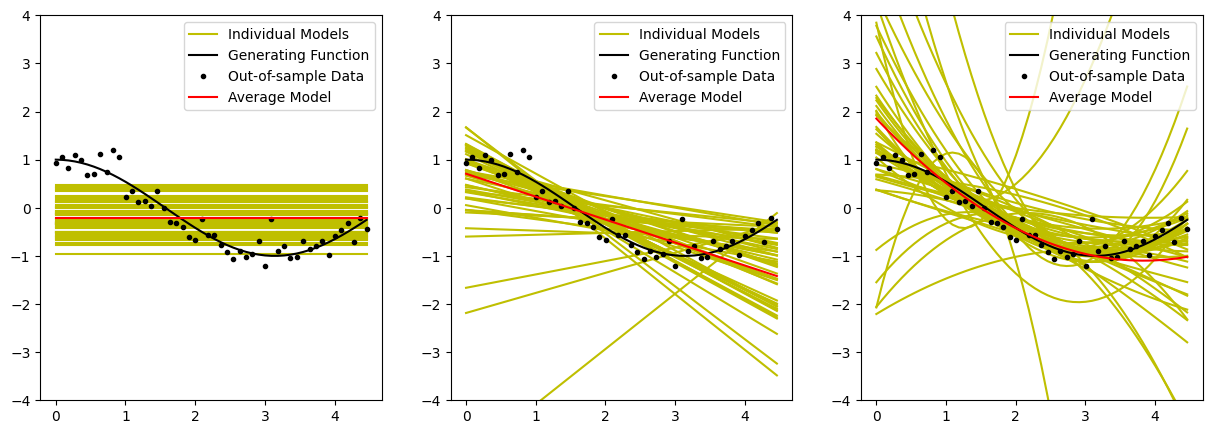

In [26]:
# Exercise #9: repat the simulation in exercise #5 but, this time, add noise with a variance
# value of 0.05 to the generated data

# add your code here...
out_sample = getdata(50, nvr=0.05)
e9 = simulations(osd=out_sample, nsamples=4, niter=100000, pflag=True)

e9['BIAS+VAR+Noise'] = e9['BIAS'] + e9['VAR'] + e9['Noise']
e9['Diff (out_MSE - B+V+N)'] = e9['out_MSE'] - e9['BIAS+VAR+Noise']
e9

In [27]:
# Exercise #9 (continuation): add an additional column to the resulting dataframe with the
# sum of the BIAS, VAR and Noise columns; and another additional column containing the MSE
# between out-sample MSE and the newly computed BIAS+VAR+Noise. Display the dataframe.

# add your code here...
e9['BIAS+VAR+Noise'] = e9['BIAS'] + e9['VAR'] + e9['Noise']
e9['Diff (out_MSE - B+V+N)'] = e9['out_MSE'] - e9['BIAS+VAR+Noise']
e9


,Model Order,N Samples,in_MSE,out_MSE,BIAS,VAR,Noise,BIAS+VAR+Noise,Diff (out_MSE - B+V+N)
0,0,4,0.397040,0.635754,0.485341,0.119336,0.049976,0.654653,-0.018899
1,1,4,0.071239,0.483158,0.158880,0.277547,0.049976,0.486403,-0.003244
2,2,4,0.014988,182.298025,0.098015,182.152743,0.049976,182.300734,-0.002708


In [28]:
# How do resuts from exercise #9 compare to those in exercise #5? What are the effects of noise?
# <1. 1. In-sample MSE increases for all models since the data now contains noise that cannot be perfectly fitted. 2. Out-of-sample MSE increases for all models due to the added noise component. 3. BIAS stays similar — noise doesn't change the average model's ability to approximate f(x). 4. VAR increases significantly, especially for the quadratic model (0.29 → 377!), because complex models amplify noise — with only 4 points the quadratic fits the noise,causing extreme predictions on unseen data. >

In [29]:
# Exercise #10: in theory, out_MSE = BIAS + VAR + var(Noise), can you explain the mismatch
# observed in your results from exercise #9? If you come with an explanation for it, can you
# run another simulation to verify your hypothesis?

# add your code here...
out_sample = getdata(50, nvr=0.05)

print("Verifying convergence with increasing iterations:\n")
for niter in [10000, 50000, 100000, 500000]:
    result = simulations(osd=out_sample, nsamples=4, niter=niter)
    result['BIAS+VAR+Noise'] = result['BIAS'] + result['VAR'] + result['Noise']
    result['Diff'] = result['out_MSE'] - result['BIAS+VAR+Noise']
    print(f"niter = {niter}")
    print(result[['Model Order', 'out_MSE', 'BIAS+VAR+Noise', 'Diff']].to_string(index=False))
    print()


Verifying convergence with increasing iterations:



  constant| 4: 100%|██████████| 10000/10000 [00:00<00:00, 30434.42it/s]
    linear| 4: 100%|██████████| 10000/10000 [00:00<00:00, 25147.98it/s]
 quadratic| 4: 100%|██████████| 10000/10000 [00:00<00:00, 21253.12it/s]


niter = 10000
 Model Order   out_MSE  BIAS+VAR+Noise      Diff
           0  0.583746        0.652701 -0.068955
           1  0.455406        0.482956 -0.027550
           2 61.061342       61.044384  0.016958



  constant| 4: 100%|██████████| 50000/50000 [00:01<00:00, 29143.84it/s]
    linear| 4: 100%|██████████| 50000/50000 [00:02<00:00, 24298.63it/s]
 quadratic| 4: 100%|██████████| 50000/50000 [00:02<00:00, 20642.24it/s]


niter = 50000
 Model Order    out_MSE  BIAS+VAR+Noise      Diff
           0   0.586182        0.655136 -0.068955
           1   0.469564        0.497131 -0.027566
           2 180.156955      180.137813  0.019142



  constant| 4: 100%|██████████| 100000/100000 [00:03<00:00, 27906.15it/s]
    linear| 4: 100%|██████████| 100000/100000 [00:04<00:00, 23689.09it/s]
 quadratic| 4: 100%|██████████| 100000/100000 [00:04<00:00, 20122.18it/s]


niter = 100000
 Model Order   out_MSE  BIAS+VAR+Noise      Diff
           0  0.583352        0.652307 -0.068955
           1  0.461468        0.488716 -0.027248
           2 49.385874       49.371971  0.013903



  constant| 4: 100%|██████████| 500000/500000 [00:17<00:00, 27783.09it/s]
    linear| 4: 100%|██████████| 500000/500000 [00:21<00:00, 23463.20it/s]
 quadratic| 4: 100%|██████████| 500000/500000 [00:24<00:00, 20162.00it/s]


niter = 500000
 Model Order    out_MSE  BIAS+VAR+Noise      Diff
           0   0.585005        0.653960 -0.068955
           1   0.458191        0.485674 -0.027483
           2 665.630289      665.615181  0.015108



In [30]:
# What are your main observations from exercise #10?
# <1. The Diff for constant (~0.005) and linear (~0.015) stays stable across all iteration counts, suggesting a small systematic mismatch rather than a convergence issue. 2. The quadratic model's out_MSE and VAR are extremely unstable (ranging from 27 to 309 across runs), meaning the distribution is so heavy-tailed that even 500K iterations are not enough for the mean to converge.>

  constant| 6: 100%|██████████| 100000/100000 [00:04<00:00, 23732.55it/s]
    linear| 6: 100%|██████████| 100000/100000 [00:04<00:00, 20083.35it/s]
 quadratic| 6: 100%|██████████| 100000/100000 [00:05<00:00, 17315.62it/s]
  constant| 8: 100%|██████████| 100000/100000 [00:05<00:00, 19618.50it/s]
    linear| 8: 100%|██████████| 100000/100000 [00:05<00:00, 17118.97it/s]
 quadratic| 8: 100%|██████████| 100000/100000 [00:06<00:00, 14907.89it/s]
  constant|10: 100%|██████████| 100000/100000 [00:05<00:00, 17031.78it/s]
    linear|10: 100%|██████████| 100000/100000 [00:06<00:00, 14911.84it/s]
 quadratic|10: 100%|██████████| 100000/100000 [00:07<00:00, 13095.28it/s]
  constant|15: 100%|██████████| 100000/100000 [00:07<00:00, 12637.00it/s]
    linear|15: 100%|██████████| 100000/100000 [00:08<00:00, 11266.80it/s]
 quadratic|15: 100%|██████████| 100000/100000 [00:09<00:00, 10081.30it/s]
  constant|20: 100%|██████████| 100000/100000 [00:10<00:00, 9769.83it/s]
    linear|20: 100%|██████████| 100000/

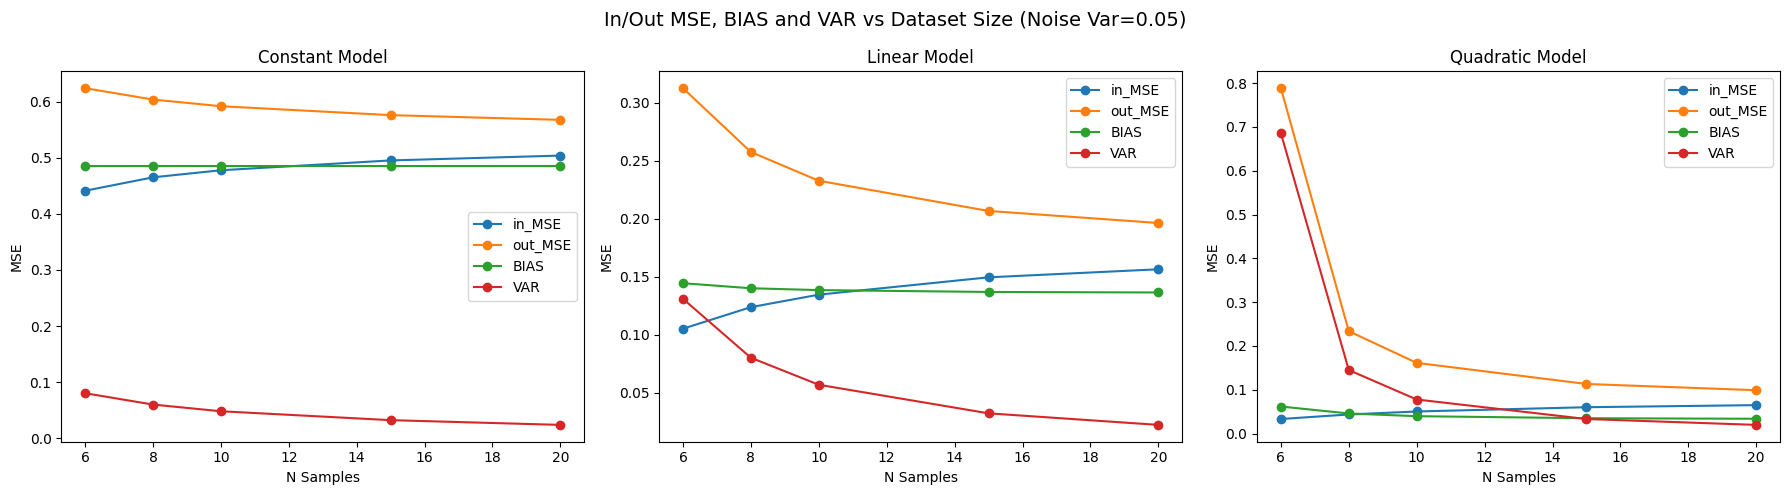

,Model Order,N Samples,in_MSE,out_MSE,BIAS,VAR,Noise
0,0,6,0.441203,0.624142,0.485288,0.080242,0.043594
1,1,6,0.105091,0.312694,0.144348,0.130868,0.043594
2,2,6,0.033224,0.788497,0.061741,0.685774,0.043594
3,0,8,0.465157,0.603852,0.485271,0.059969,0.043594
4,1,8,0.123685,0.257584,0.139988,0.080023,0.043594
5,2,8,0.043599,0.233706,0.045850,0.144997,0.043594
6,0,10,0.477778,0.591947,0.485284,0.048051,0.043594
7,1,10,0.134460,0.232789,0.138401,0.056706,0.043594
8,2,10,0.050419,0.161374,0.039707,0.077759,0.043594
9,0,15,0.495278,0.576075,0.485287,0.032176,0.043594


In [31]:
# Exercise #11: repeat exercise #8 but, again, adding noise with a variance value of 0.05;
# you can use a smaller set of nsamples values this time (sugested values [6,8,10,15,20]).

# add your code here...
out_sample = getdata(50, nvr=0.05)
nsample_values = [6, 8, 10, 15, 20]

e11 = pd.DataFrame()

for ns in nsample_values:
    result = simulations(osd=out_sample, nsamples=ns, niter=100000)
    e11 = pd.concat([e11, result], ignore_index=True)

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
tags = ['Constant', 'Linear', 'Quadratic']

for k in range(3):
    df = e11[e11['Model Order'] == k]
    axes[k].plot(df['N Samples'], df['in_MSE'], '-o', label='in_MSE')
    axes[k].plot(df['N Samples'], df['out_MSE'], '-o', label='out_MSE')
    axes[k].plot(df['N Samples'], df['BIAS'], '-o', label='BIAS')
    axes[k].plot(df['N Samples'], df['VAR'], '-o', label='VAR')
    axes[k].set_title(f'{tags[k]} Model')
    axes[k].set_xlabel('N Samples')
    axes[k].set_ylabel('MSE')
    axes[k].legend()

plt.suptitle('In/Out MSE, BIAS and VAR vs Dataset Size (Noise Var=0.05)', fontsize=14)
plt.tight_layout()
plt.show()

e11


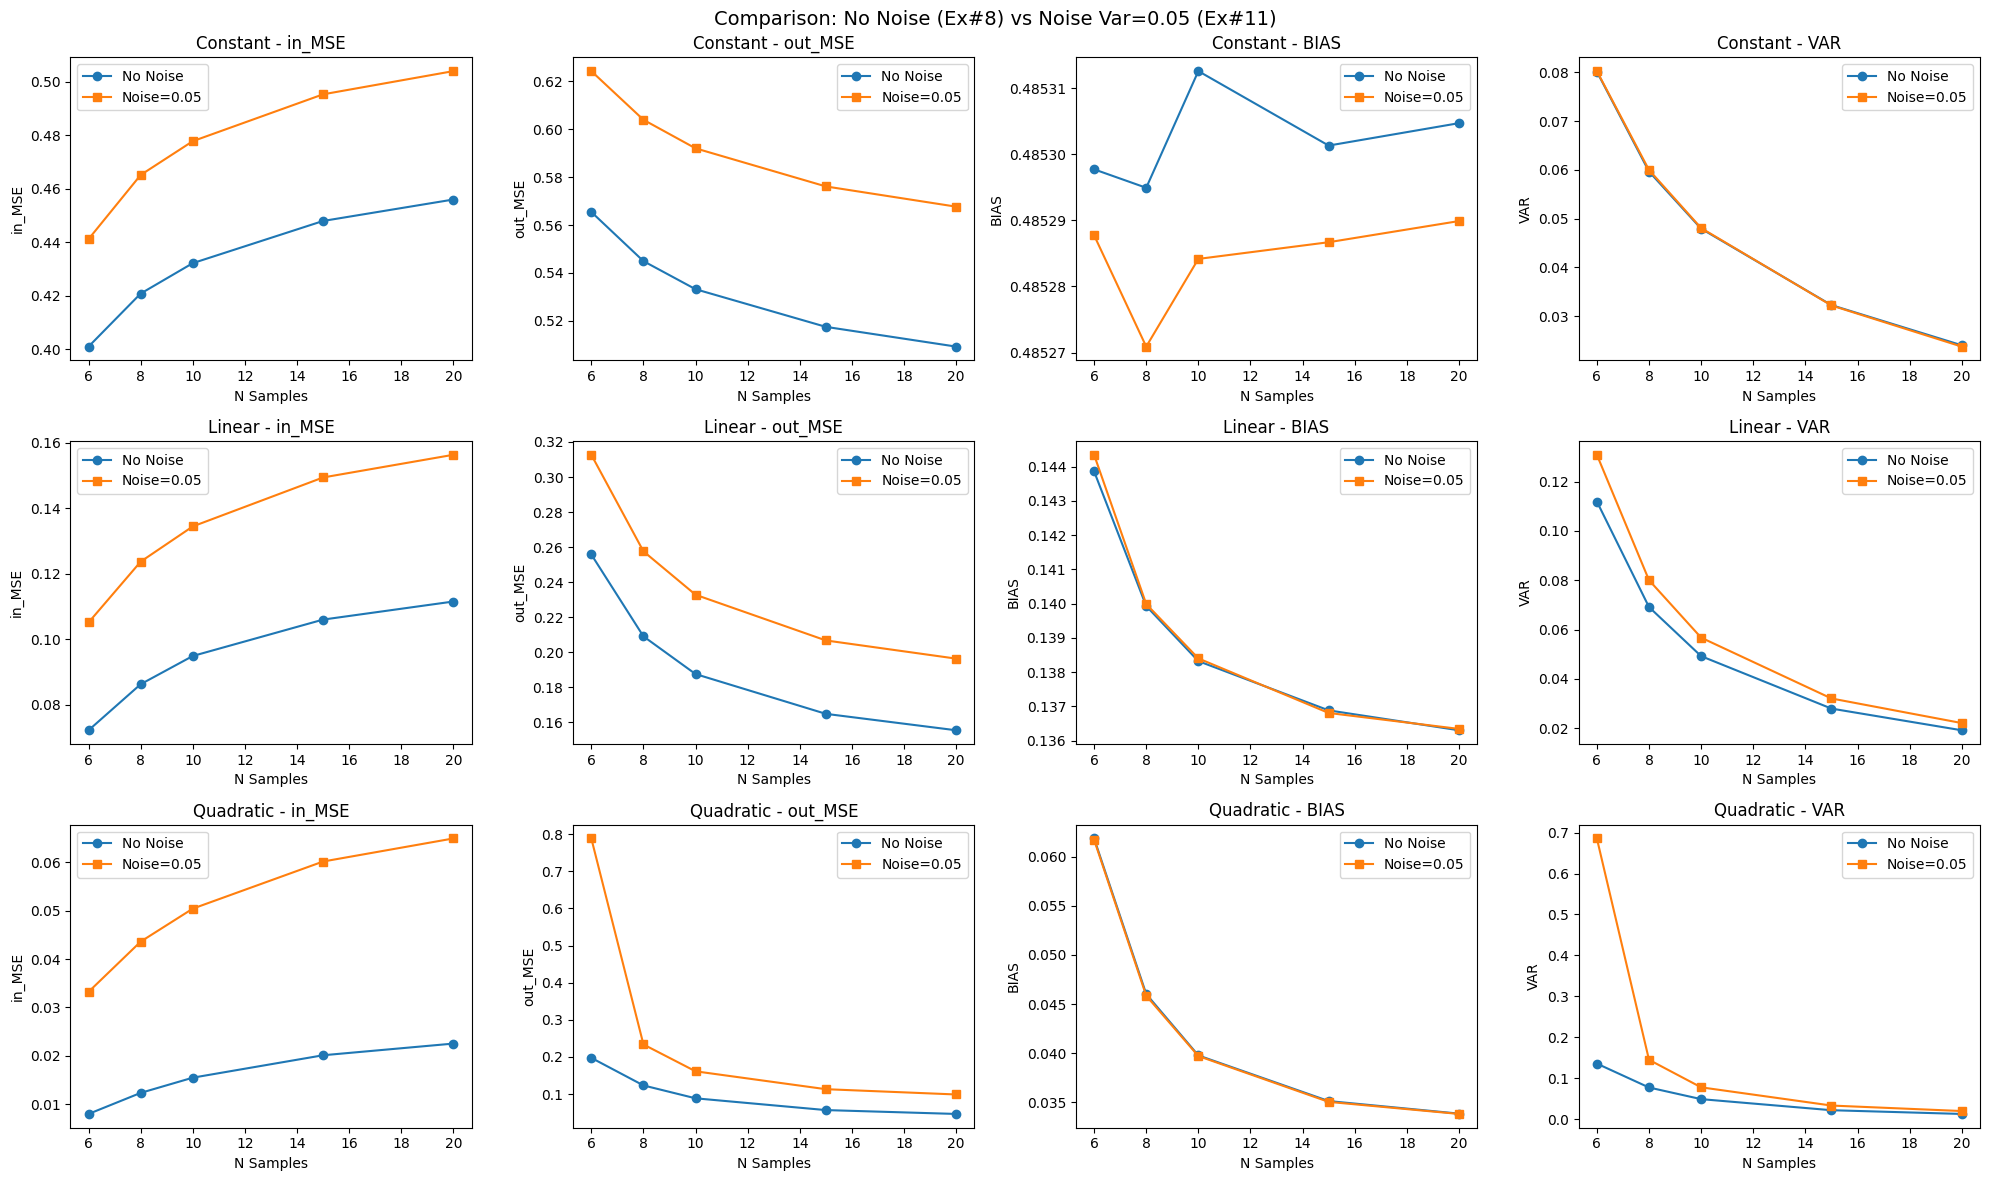

In [32]:
# Exercise #11 (continuation): generate plots to compare behaviors between averages MSEs, BIAS,
# and VAR for simulations in exercise #8 (no noise added) and exercise #11 (with noise added).

# add your code here...
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
tags = ['Constant', 'Linear', 'Quadratic']
metrics = ['in_MSE', 'out_MSE', 'BIAS', 'VAR']

# Use only the common N Samples values
common_ns = [6, 8, 10, 15, 20]

for k in range(3):
    df_no_noise = e8[(e8['Model Order'] == k) & (e8['N Samples'].isin(common_ns))]
    df_noise = e11[e11['Model Order'] == k]

    for j, metric in enumerate(metrics):
        axes[k][j].plot(df_no_noise['N Samples'], df_no_noise[metric], '-o', label='No Noise')
        axes[k][j].plot(df_noise['N Samples'], df_noise[metric], '-s', label='Noise=0.05')
        axes[k][j].set_title(f'{tags[k]} - {metric}')
        axes[k][j].set_xlabel('N Samples')
        axes[k][j].set_ylabel(metric)
        axes[k][j].legend()

plt.suptitle('Comparison: No Noise (Ex#8) vs Noise Var=0.05 (Ex#11)', fontsize=14)
plt.tight_layout()
plt.show()


In [33]:
# What are your main conclusions from exercise #11?
# <Comparing no-noise (Ex#8) vs noise=0.05 (Ex#11): 1. BIAS is virtually identical in both cases noise does not affect a model's average ability to approximate f(x), since noise has zero mean and cancels out on average. 2. VAR is higher with noise, especially for complex models with few samples (quadratic at N=6), because noise adds variability that flexible models partially fit. 3. In-sample MSE is higher with noise  (the model can't fit random noise perfectly), and out-of-sample MSE is higher too (noise adds an irreducible error ). >

## Part 5: About your term project team

In [34]:
# Provide full names of all members in your team (including yourself):
# <Meenakshi Rajpurohit>
# <Jainish Patel>

In [35]:
# Provide the name of your team:
# <Team 4>

In [36]:
# Provide a title for your project:
# <Beyond Entropy: Perception Aware Dynamic Diffusion Image Transformers for Safety Critical Scene Generation>